# Wine Quality Prediction Using Machine Learning

## Objective

The objective of this project is to analyze the chemical properties of wine
and build machine learning models to predict wine quality.

The project includes:
- Data loading
- Data understanding
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Train-test splitting
- Feature scaling
- Machine learning model training
- Model comparison
- Evaluation on unseen test data
- Final conclusions

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## Step 1: Loading the Dataset

The dataset contains information about the chemical properties of wine.
These properties will be used as input features for predicting wine quality.

In [31]:
wine = load_wine(as_frame=True)

df = wine.frame

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Step 2: Understanding the Dataset

Before performing machine learning, we need to understand the structure
of the dataset, the number of observations, available features, and
the target variable.

In [33]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 178
Number of columns: 14

Column names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']

Data types:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object


## Dataset Information

The `info()` function provides information about:
- Number of records
- Column names
- Data types
- Non-null values

This helps us identify missing values and understand the dataset structure.

In [34]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (178, 14)

Column Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins   

## Statistical Summary

Descriptive statistics are used to understand the distribution of numerical
features. Measures such as mean, standard deviation, minimum, maximum,
and quartiles are examined.

In [35]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## Missing Value Analysis

Missing values can affect machine learning models.
Therefore, we check every column for missing observations.

In [36]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Total missing values: 0


## Duplicate Record Analysis

Duplicate records may occur when the same observation is present more
than once. We identify duplicate rows before building the model.

In [37]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [38]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (178, 14)


### Observation

Duplicate records were removed to avoid giving repeated observations
additional influence during model training.

## Target Variable Distribution

The `quality` column represents the quality score assigned to each wine.
We examine its distribution to understand how many samples belong to
each quality category.

Target class counts:
target
0    59
1    71
2    48
Name: count, dtype: int64


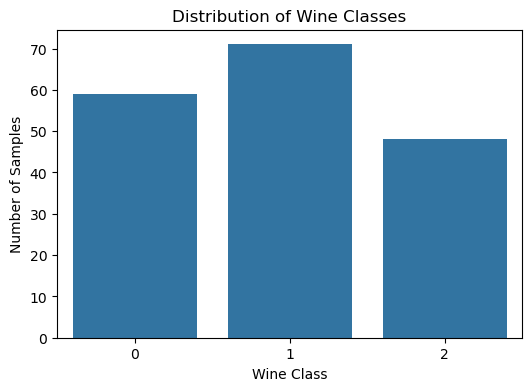

In [39]:
print("Target class counts:")
print(df["target"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)
plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.show()

### Observation

The target classes are not equally distributed. Some wine quality scores
contain considerably more observations than others.

This class imbalance should be considered when interpreting model accuracy.

## Feature Distribution Analysis

Histograms are used to understand the distribution of the numerical
features in the dataset.

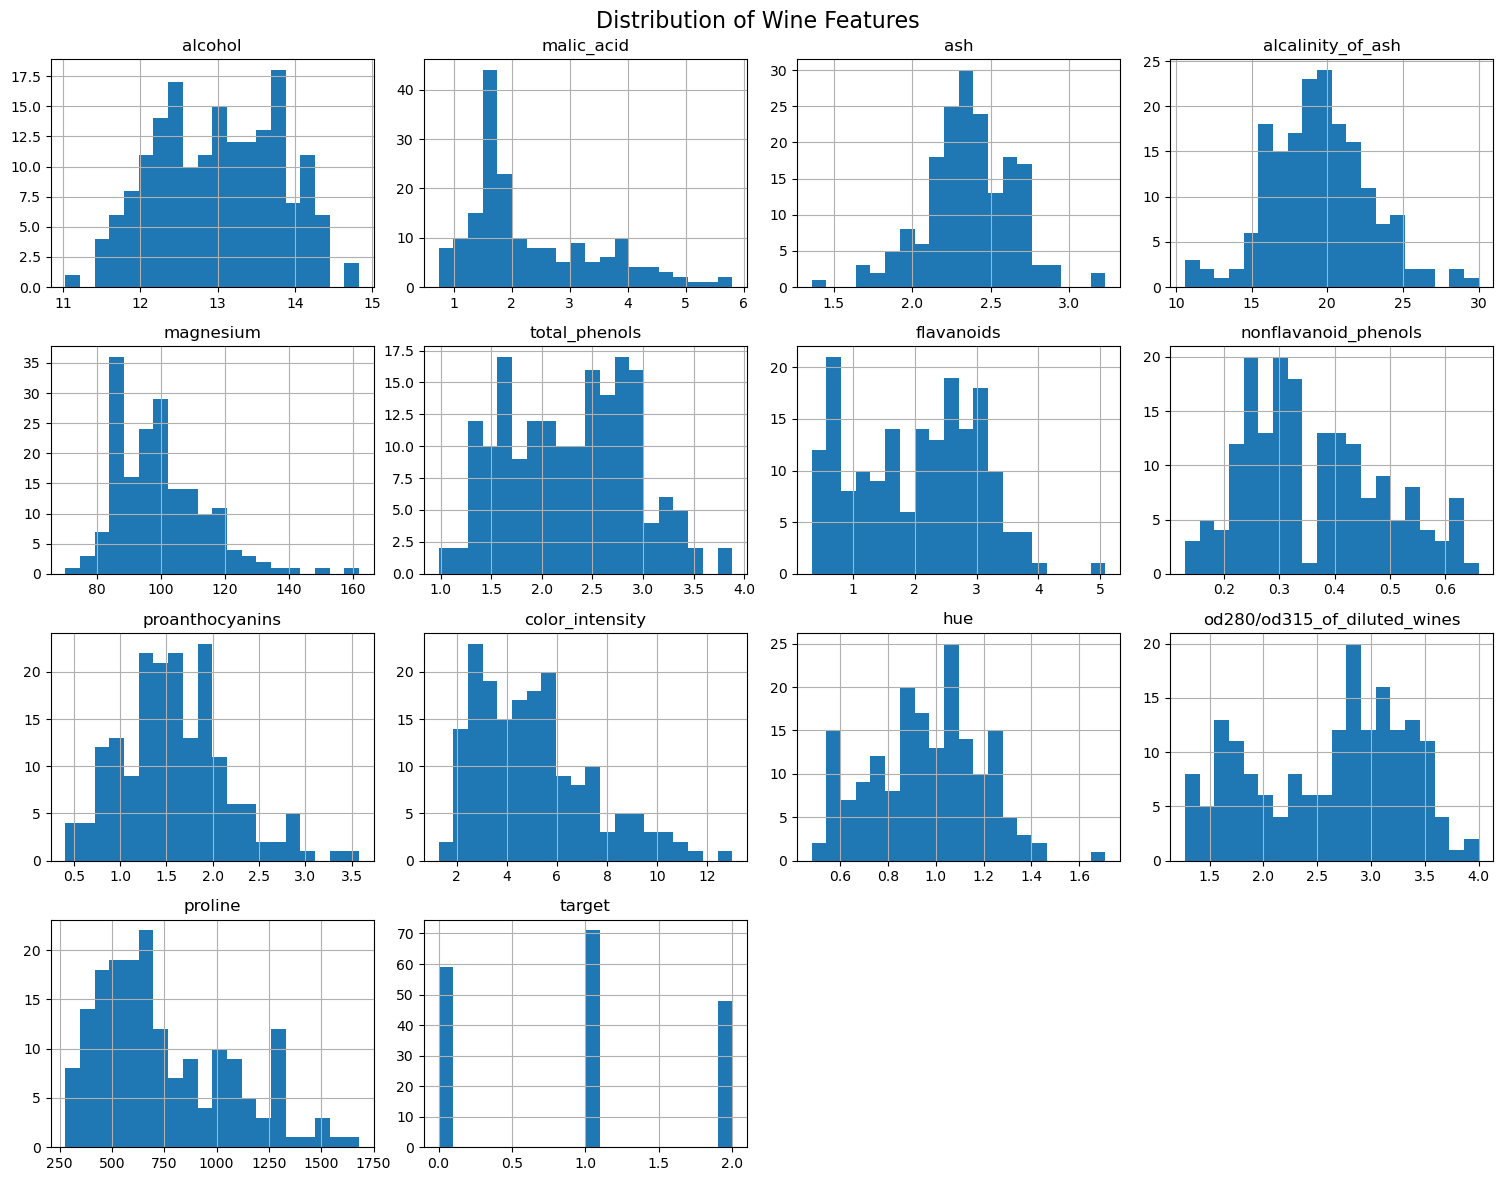

In [42]:
df.hist(figsize=(15, 12), bins=20)

plt.suptitle("Distribution of Wine Features", fontsize=16)
plt.tight_layout()

plt.show()

## Correlation Analysis

Correlation measures the relationship between numerical variables.

A heatmap is used to identify strongly related features and to understand
the relationship between the chemical properties and wine quality.

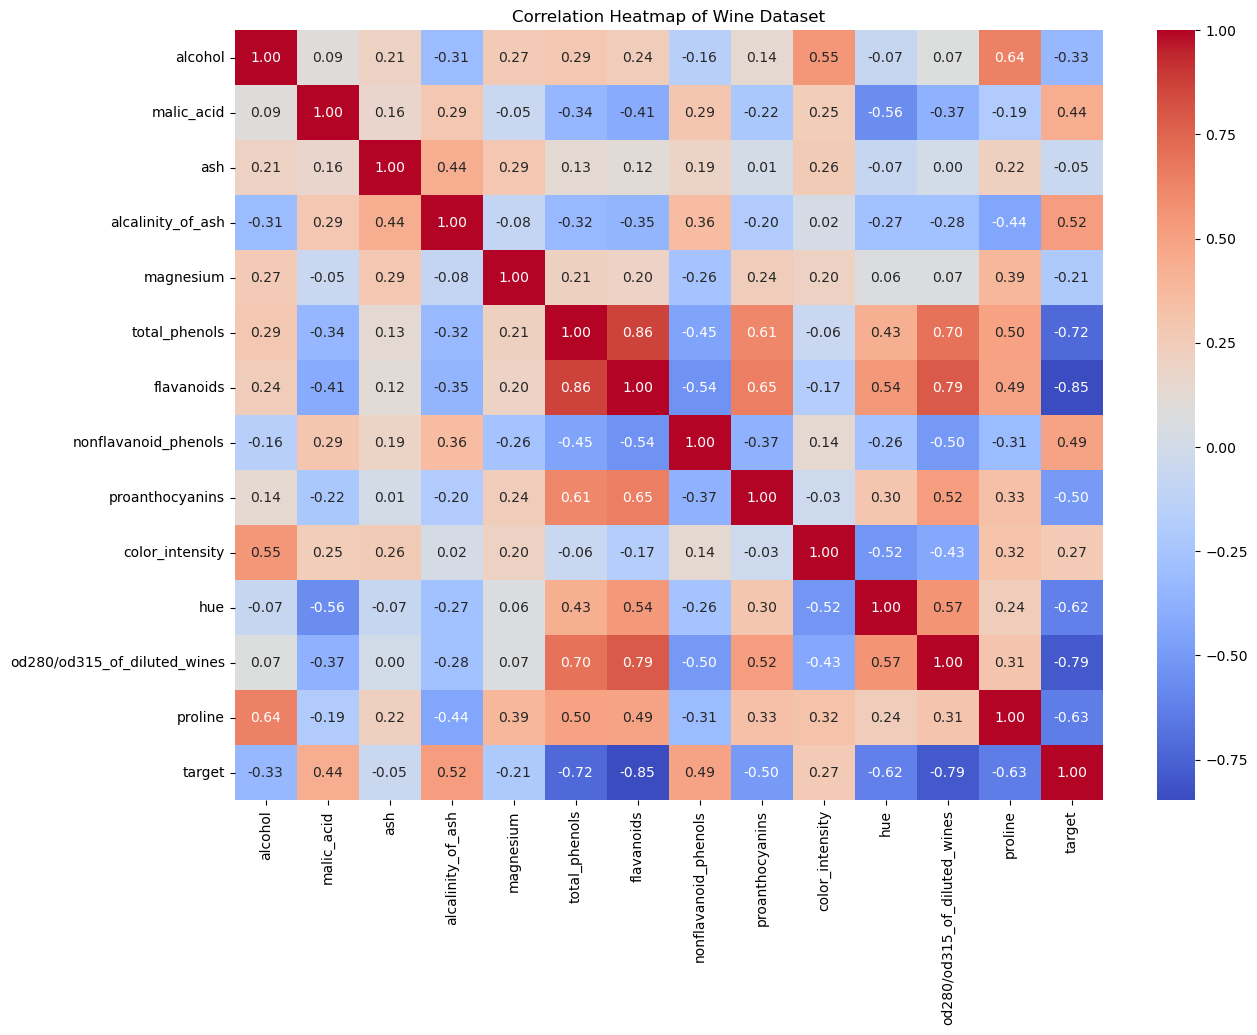

In [43]:
plt.figure(figsize=(14, 10))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Wine Dataset")
plt.show()

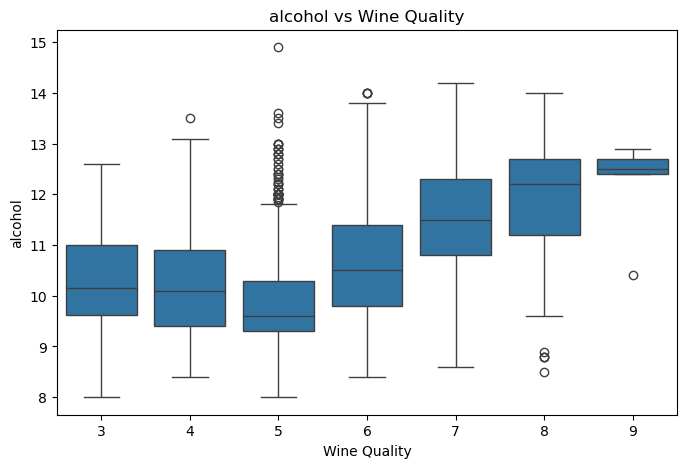

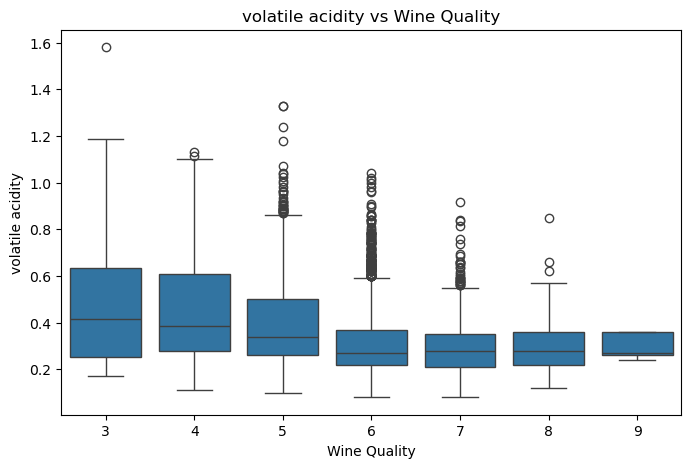

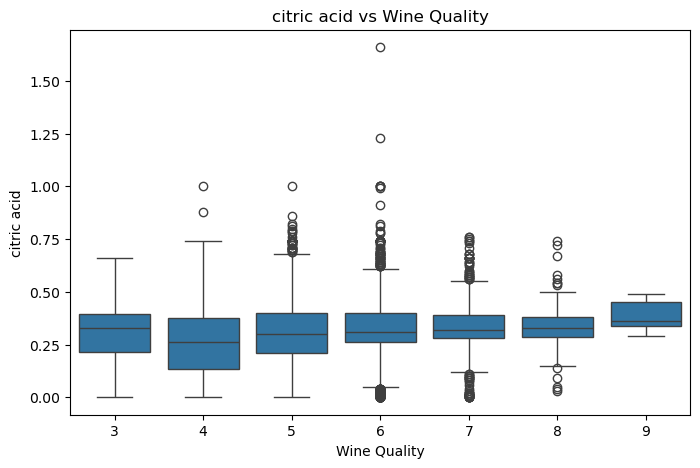

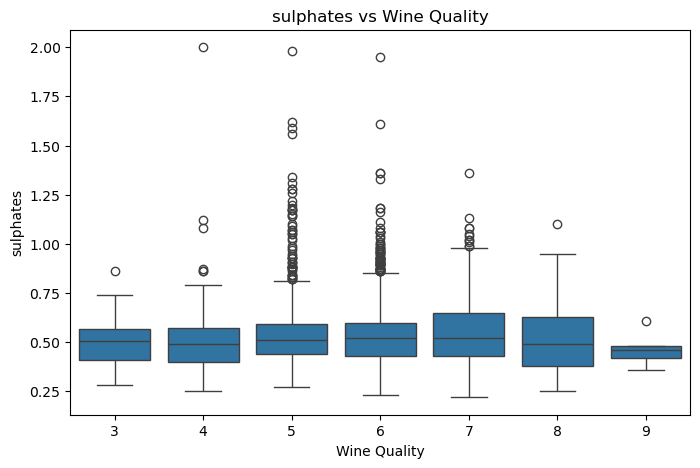

In [16]:
features_to_plot = [
    "alcohol",
    "volatile acidity",
    "citric acid",
    "sulphates"
]

for feature in features_to_plot:
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=df, x="quality", y=feature)

    plt.title(f"{feature} vs Wine Quality")
    plt.xlabel("Wine Quality")
    plt.ylabel(feature)

    plt.show()

## Wine Type Distribution

The dataset contains both red and white wines.

We examine the number of observations belonging to each wine type to
understand the composition of the dataset.

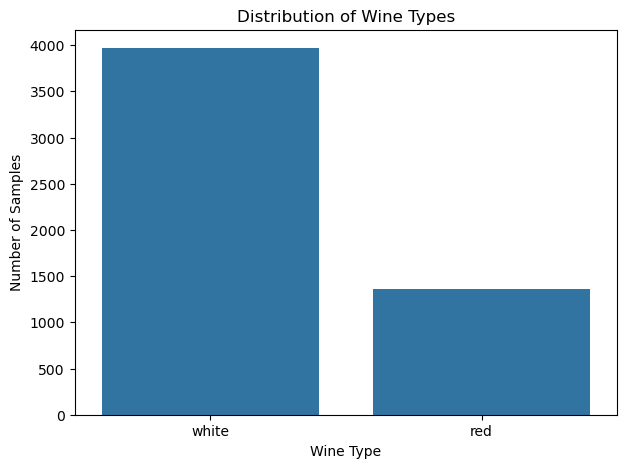

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="type")

plt.title("Distribution of Wine Types")
plt.xlabel("Wine Type")
plt.ylabel("Number of Samples")

plt.show()

## Wine Type and Quality

We compare the quality distribution of red and white wines to determine
whether wine type is associated with differences in quality scores.

## Feature and Target Separation

The dataset is divided into input features and the target variable.

- X contains the chemical properties of the wine and the wine type.
- y contains the wine quality score that the model needs to predict.

In [45]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (178, 13)
Target shape: (178,)


## Encoding Categorical Features

The `type` column contains categorical values such as red and white.

Machine learning algorithms require numerical input, so the categorical
wine type is converted into numerical columns using one-hot encoding.

The `drop_first=True` option avoids creating redundant information.

In [20]:
X = pd.get_dummies(
    X,
    columns=["type"],
    drop_first=True,
    dtype=int
)

print("Features after encoding:")
print(X.columns.tolist())

print("\nNew feature shape:", X.shape)

X.head()

Features after encoding:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type_white']

New feature shape: (5328, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_white
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,1
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,1


## Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% of the data is reserved for testing.

The test data is not used during model training and will represent
unseen data for the final evaluation.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (142, 13)
Testing data: (36, 13)


## Feature Scaling

The numerical features have different ranges.

StandardScaler is used to standardize the features before training
algorithms that are sensitive to feature magnitude.

The scaler is fitted only on the training data to prevent information
from the test set from leaking into the training process.

In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Testing data scaled successfully.")

Training data scaled successfully.
Testing data scaled successfully.


## 11. Machine Learning Model Training and Evaluation

In [48]:
# Create models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": SVC(kernel="rbf")
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"{name} Accuracy: {accuracy * 100:.2f}%")

Logistic Regression Accuracy: 97.22%
KNN Accuracy: 97.22%
Decision Tree Accuracy: 94.44%
Random Forest Accuracy: 100.00%
SVM Accuracy: 97.22%


## 12. Final Model Evaluation - Random Forest

In [49]:
# Train the final Random Forest model
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

final_model.fit(X_train_scaled, y_train)

# Predictions on unseen test data
y_pred_final = final_model.predict(X_test_scaled)

# Final accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)

print(f"Final Random Forest Accuracy: {final_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Final Random Forest Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 13. Confusion Matrix

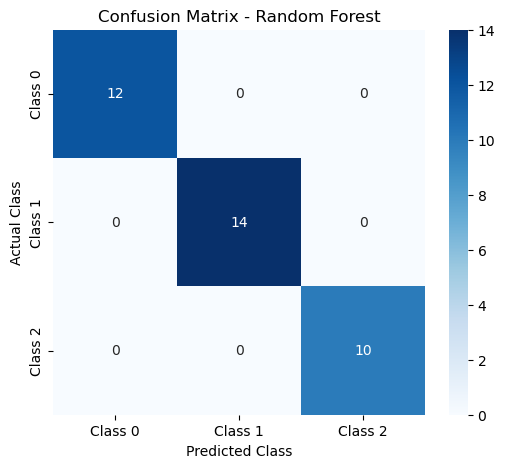

In [50]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1", "Class 2"],
    yticklabels=["Class 0", "Class 1", "Class 2"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## 14. Feature Importance Analysis

                         Feature  Importance
9                color_intensity    0.187404
6                     flavanoids    0.168373
12                       proline    0.157024
0                        alcohol    0.108171
10                           hue    0.094966
11  od280/od315_of_diluted_wines    0.089898
5                  total_phenols    0.051274
4                      magnesium    0.035210
1                     malic_acid    0.030246
8                proanthocyanins    0.028266
3              alcalinity_of_ash    0.026168
2                            ash    0.014577
7           nonflavanoid_phenols    0.008423


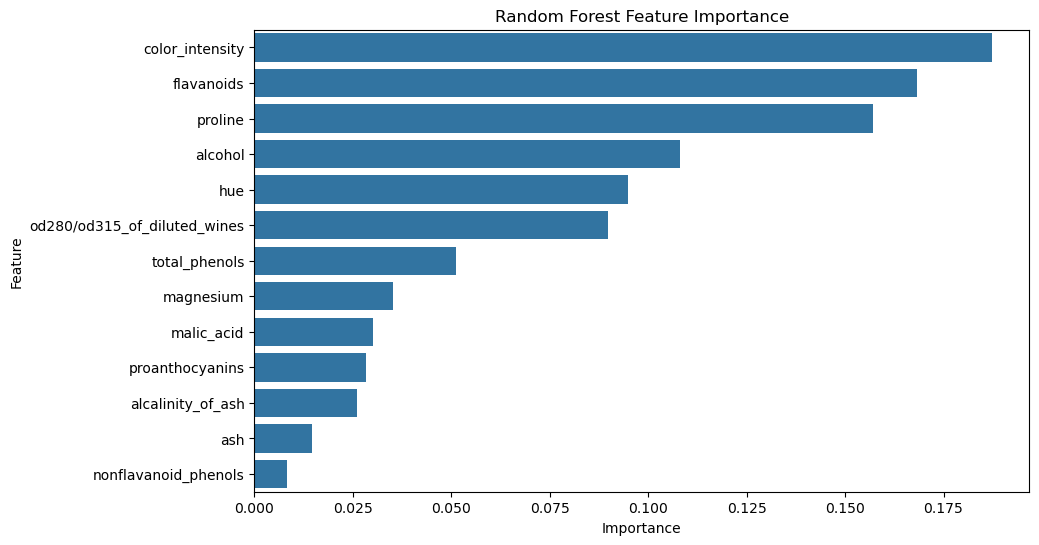

In [51]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 15. Final Model Comparison

In [54]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy (%)": [
        97.22,
        97.22,
        94.44,
        100.00,
        97.22
    ]
})

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print(results_df.to_string(index=False))

              Model  Accuracy (%)
      Random Forest        100.00
Logistic Regression         97.22
                KNN         97.22
                SVM         97.22
      Decision Tree         94.44


## 16. Conclusion

### Conclusion

The Wine Classification dataset was analyzed and classified using
five different machine learning algorithms: Logistic Regression, KNN,
Decision Tree, Random Forest, and SVM.

The dataset was divided into 80% training data and 20% testing data.
Feature scaling was performed using StandardScaler, with the scaler
fitted only on the training data to prevent data leakage.

The models achieved the following test accuracies:

- Logistic Regression: 97.22%
- KNN: 97.22%
- Decision Tree: 94.44%
- Random Forest: 100.00%
- SVM: 97.22%

Random Forest achieved 100.00% accuracy on the unseen test set for
the selected 80:20 train-test split, correctly classifying all 36 test
samples.

Therefore, the Random Forest model provided the highest test accuracy
among the models evaluated in this experiment.